In [1]:
import numpy as np
import matplotlib.pylab as plt
from parameters import * # import parameters and units
import brian2 as brian # import the whole module

In [2]:
# --- synaptic parameters (single-exponential conductance) ---
Esyn    = 0*mV      # excitatory reversal potential
tau_syn = 5*ms
w       = 5*nS       # conductance jump per presynaptic spike

eqs = '''
dv/dt = (-gL*(v - El) - g_syn*(v - Esyn)) / Cm : volt
dg_syn/dt = -g_syn / tau_syn : siemens
'''

neuron = brian.NeuronGroup(1, eqs, 
                           threshold='v>Vt', reset='v=Vr',
                            method='exponential_euler')
neuron.v = El
neuron.g_syn = 0*nS

# --- a few synaptic events --- #
input_times = [50, 104, 108, 162, 166, 168, 175, 178, 185]*ms
presyn = brian.SpikeGeneratorGroup(1, [0]*len(input_times), input_times)

# connecting those events to the synapse
syn = brian.Synapses(presyn, neuron, on_pre='g_syn += w')
syn.connect()

mon    = brian.StateMonitor(neuron, ['v', 'g_syn'], record=0)
spikes = brian.SpikeMonitor(neuron)
# --- now just use the run function
brian.run(250*ms)

print(f'Number of postsynaptic spikes: {spikes.count[0]}')

Number of postsynaptic spikes: 1


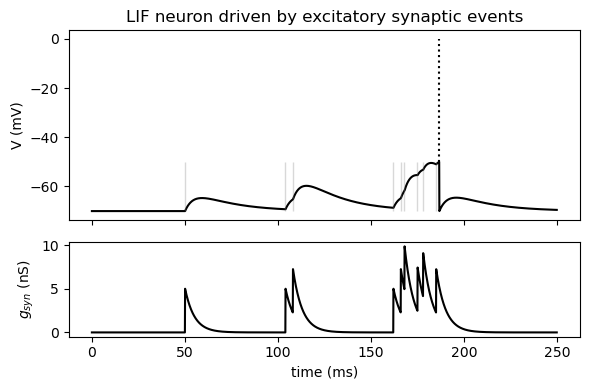

In [3]:
from plots import plot_with_spikes
# --- plot ---
fig, (ax_v, ax_g) = plt.subplots(2, 1, figsize=(6, 4), sharex=True,
                                  gridspec_kw={'height_ratios': [2, 1]})

plot_with_spikes(ax_v, mon, 0)
ax_v.vlines(input_times/ms, Vr/mV, Vt/mV, color='grey', alpha=0.3, lw=1)
ax_v.set_ylabel('V (mV)')
ax_v.set_title('LIF neuron driven by excitatory synaptic events')

ax_g.plot(mon.t/ms, mon.g_syn[0]/nS, 'k-')
ax_g.set_xlabel('time (ms)')
ax_g.set_ylabel('$g_{syn}$ (nS)')

plt.tight_layout()
plt.show()